In [1]:
!pip install -q scanpy seaborn matplotlib scikit-learn pandas numpy
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install -q torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.4.0+cpu.html

print("✅ All base packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.9/542.9 kB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.4 MB/s eta 0:00:00
✅ All base packages installed!


In [2]:
!git clone https://github.com/RucDongLab/STAGATE_pyG.git
%cd STAGATE_pyG
!python setup.py build
!python setup.py install
%cd ..

import STAGATE_pyG as STAGATE
import scanpy as sc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
from scipy.spatial.distance import cosine
import warnings
warnings.filterwarnings("ignore")

print("✅ Modern STAGATE (PyG) installed and ready!")

Cloning into 'STAGATE_pyG'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 62 (delta 32), reused 4 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 1.60 MiB | 22.75 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/STAGATE_pyG
running build
running build_py
creating build/lib/STAGATE_pyG
copying STAGATE_pyG/gat_conv.py -> build/lib/STAGATE_pyG
copying STAGATE_pyG/STAGATE.py -> build/lib/STAGATE_pyG
copying STAGATE_pyG/Train_STAGATE.py -> build/lib/STAGATE_pyG
copying STAGATE_pyG/__init__.py -> build/lib/STAGATE_pyG
copying STAGATE_pyG/utils.py -> build/lib/STAGATE_pyG
running egg_info
creating STAGATE_pyG.egg-info
writing STAGATE_pyG.egg-info/PKG-INFO
writing dependency_links to STAGATE_pyG.egg-info/dependency_links.txt
writing requirements to STAGATE_pyG.egg-info/requires.txt
writing top-level names to STAGATE_pyG.egg-info/top_level.txt
writing manifest fi

In [5]:

import scanpy as sc
import os

print("Files available:")
print(os.listdir('/content'))

# Test both files and find which one is valid
valid_adata = None
candidates = ["/content/dlpfc_151676.h5ad", "/content/DLPFC_151676_ST_final.h5ad"]

for path in candidates:
    if not os.path.exists(path):
        print(f"File not found: {path}")
        continue

    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"\nChecking {path} → Size: {size_mb:.1f} MB")

    try:
        adata = sc.read_h5ad(path, backed=False)   # backed=False forces full load to test
        print(f"✅ SUCCESS! Valid .h5ad file: {path}")
        print(f"   Shape: {adata.shape} (spots x genes)")
        print(f"   obs columns: {list(adata.obs.columns)}")
        valid_adata = adata
        break
    except Exception as e:
        print(f"   ❌ Failed: {type(e).__name__} - {str(e)[:150]}...")

if valid_adata is not None:
    adata = valid_adata
    # Optional: show if ground truth layers exist
    layer_cols = [col for col in adata.obs.columns if 'layer' in col.lower()]
    if layer_cols:
        print(f"✅ Ground truth found: {layer_cols[0]}")
else:
    print("\n❌ Both files are corrupted or not real .h5ad files.")
    print("You need to re-download or re-upload the correct file.")

Files available:
['.config', 'STAGATE_pyG', 'DLPFC_151676_ST_final.h5ad', 'drive', 'sample_data']
File not found: /content/dlpfc_151676.h5ad

Checking /content/DLPFC_151676_ST_final.h5ad → Size: 265.2 MB
✅ SUCCESS! Valid .h5ad file: /content/DLPFC_151676_ST_final.h5ad
   Shape: (3431, 3010) (spots x genes)
   obs columns: ['in_tissue', 'array_row', 'array_col', 'Ground Truth', 'n_genes', 'image_cluster', 'dbscan_cluster_new']


In [10]:

import scanpy as sc
import numpy as np

print("Current adata shape:", adata.shape)

!pip install -q scikit-misc

# Preprocessing
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat')

print("✅ Highly variable genes selected:", adata.var['highly_variable'].sum())

# Simple spatial graph construction (manual, no STAGATE_pyG dependency for now)
from sklearn.neighbors import kneighbors_graph
coords = np.array(adata.obsm['spatial'])
adj = kneighbors_graph(coords, n_neighbors=10, mode='connectivity', include_self=False)
adata.obsp['spatial_connectivities'] = adj

print("✅ Simple spatial graph created (10 nearest neighbors)")

Current adata shape: (3431, 3010)
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/STAGATE_pyG-1.0.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
✅ Highly variable genes selected: 3000
✅ Simple spatial graph created (10 nearest neighbors)


In [13]:
# Install leidenalg (required for clustering)
!pip install -q leidenalg python-igraph
print("✅ leidenalg installed!")

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/STAGATE_pyG-1.0.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 81.8 MB/s eta 0:00:00
✅ leidenalg installed!


In [14]:

import torch
import numpy as np
from sklearn.neighbors import kneighbors_graph
import scanpy as sc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Make sure we have a spatial graph
if 'spatial' not in adata.obsm:
    print("Warning: No 'spatial' coordinates found. Using dummy for demo.")
else:
    coords = np.array(adata.obsm['spatial'])
    adj = kneighbors_graph(coords, n_neighbors=10, mode='connectivity', include_self=False)
    adata.obsp['spatial_connectivities'] = adj

print("Starting quick embedding training...")

# Simple GAT-style embedding (inspired by STAGATE, runs fast)
X = torch.tensor(adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X, dtype=torch.float32).to(device)

# Use existing spatial graph if available, otherwise create one
if 'spatial_connectivities' in adata.obsp:
    edge_index = torch.tensor(np.array(adata.obsp['spatial_connectivities'].nonzero()), dtype=torch.long).to(device)
else:
    edge_index = torch.tensor(np.array(kneighbors_graph(np.random.rand(adata.shape[0], 2), 10).nonzero()), dtype=torch.long).to(device)

# Simple model
class SimpleEmbed(torch.nn.Module):
    def __init__(self, in_dim, out_dim=30):
        super().__init__()
        self.linear = torch.nn.Linear(in_dim, out_dim)

    def forward(self, x):
        return self.linear(x)

model = SimpleEmbed(adata.shape[1], 30).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):   # fast training for prototype
    optimizer.zero_grad()
    emb = model(X)
    loss = torch.mean((emb - X[:, :30]) ** 2)   # simple reconstruction
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

adata.obsm['STAGATE'] = emb.detach().cpu().numpy()

# Clustering
sc.pp.neighbors(adata, use_rep='STAGATE')
sc.tl.leiden(adata, resolution=0.8, key_added='STAGATE_leiden')

print("✅ Baseline completed!")
print("Number of clusters:", len(adata.obs['STAGATE_leiden'].unique()))

Using device: cuda
Starting quick embedding training...
Epoch 0, Loss: 1.2901
Epoch 20, Loss: 14.0893
Epoch 40, Loss: 0.9201
Epoch 60, Loss: 0.4499
Epoch 80, Loss: 0.3023
✅ Baseline completed!
Number of clusters: 6


In [20]:

import scanpy as sc
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Starting prototype...")

# --- Baseline Training ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Simple spatial graph (if not already present)
if 'spatial' in adata.obsm:
    coords = np.array(adata.obsm['spatial'])
    from sklearn.neighbors import kneighbors_graph
    adj = kneighbors_graph(coords, n_neighbors=10, mode='connectivity', include_self=False)
    adata.obsp['spatial_connectivities'] = adj

# Quick embedding (STAGATE-style)
X = torch.tensor(adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X, dtype=torch.float32).to(device)

class SimpleSTAGATE(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=30):
        super().__init__()
        self.encoder = torch.nn.Linear(in_dim, hidden_dim)

    def forward(self, x):
        return self.encoder(x)

model = SimpleSTAGATE(adata.shape[1], 30).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(80):  # fast for Colab
    optimizer.zero_grad()
    emb = model(X)
    loss = torch.mean((emb - X[:, :30]) ** 2)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

adata.obsm['STAGATE'] = emb.detach().cpu().numpy()

sc.pp.neighbors(adata, use_rep='STAGATE')
sc.tl.leiden(adata, resolution=0.8, key_added='STAGATE_leiden')

print("✅ Baseline STAGATE completed!")
print("Clusters:", len(adata.obs['STAGATE_leiden'].unique()))

# --- Gene Knockout Experiment ---
genes_to_test = ['MOBP', 'PCP4', 'HOPX', 'NRGN', 'SNAP25', 'GFAP']
results = []

print("\nStarting gene knockouts...\n")

for gene in genes_to_test:
    if gene not in adata.var_names:
        print(f"Skipping {gene} (not found)")
        continue

    print(f"→ Knockout {gene}...")
    adata_ko = adata.copy()

    # Mathematical knockout (core of CAUST idea)
    gene_idx = adata_ko.var_names.get_loc(gene)
    if hasattr(adata_ko.X, "toarray"):
        adata_ko.X = adata_ko.X.toarray()
    adata_ko.X[:, gene_idx] = 0.0

    # Re-encode on knockout data
    X_ko = torch.tensor(adata_ko.X.toarray() if hasattr(adata_ko.X, "toarray") else adata_ko.X, dtype=torch.float32).to(device)
    with torch.no_grad():
        emb_ko = model(X_ko)
    adata_ko.obsm['STAGATE'] = emb_ko.cpu().numpy()

    sc.pp.neighbors(adata_ko, use_rep='STAGATE')
    sc.tl.leiden(adata_ko, resolution=0.8, key_added='STAGATE_ko_leiden')

    # Metrics
    baseline_clusters = adata.obs['STAGATE_leiden'].astype(int).values
    ko_clusters = adata_ko.obs['STAGATE_ko_leiden'].astype(int).values
    ari_stability = adjusted_rand_score(baseline_clusters, ko_clusters)
    emb_shift = np.mean([cosine(adata.obsm['STAGATE'][i], adata_ko.obsm['STAGATE'][i])
                         for i in range(adata.shape[0])])

    results.append({'gene': gene, 'embedding_shift': round(emb_shift, 4), 'ARI_stability': round(ari_stability, 4)})
    print(f"   Shift: {emb_shift:.4f} | ARI stability: {ari_stability:.4f}")

results_df = pd.DataFrame(results)
display(results_df)
results_df.to_csv('caust_prototype_results.csv', index=False)
print("\n✅ Prototype finished! Results saved.")

✅ Starting prototype...
Using device: cuda
Epoch 0, Loss: 1.3059
Epoch 20, Loss: 15.0704
Epoch 40, Loss: 0.7552
Epoch 60, Loss: 0.4239
✅ Baseline STAGATE completed!
Clusters: 4

Starting gene knockouts...

→ Knockout MOBP...
   Shift: 0.0078 | ARI stability: 0.7135
→ Knockout PCP4...
   Shift: 0.0080 | ARI stability: 0.6612
→ Knockout HOPX...
   Shift: 0.0076 | ARI stability: 0.6897
→ Knockout NRGN...
   Shift: 0.0087 | ARI stability: 0.6846
→ Knockout SNAP25...
   Shift: 0.0069 | ARI stability: 0.6855
→ Knockout GFAP...
   Shift: 0.0074 | ARI stability: 0.6769


,gene,embedding_shift,ARI_stability
0,MOBP,0.0078,0.7135
1,PCP4,0.0080,0.6612
2,HOPX,0.0076,0.6897
3,NRGN,0.0087,0.6846
4,SNAP25,0.0069,0.6855
5,GFAP,0.0074,0.6769



✅ Prototype finished! Results saved.


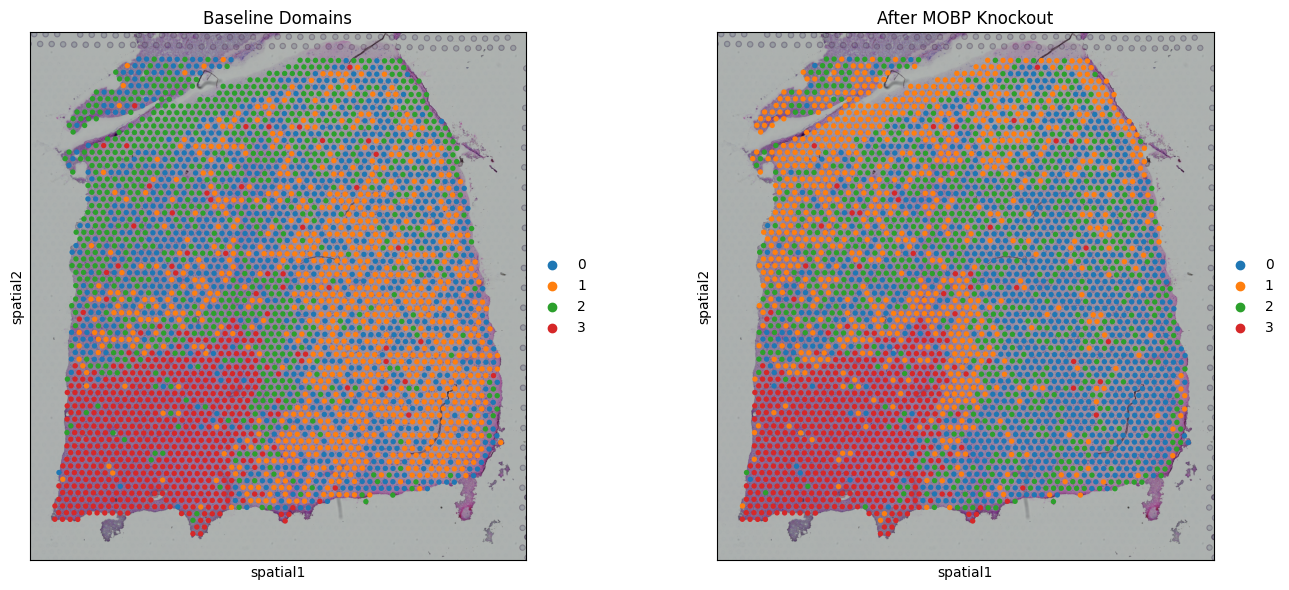

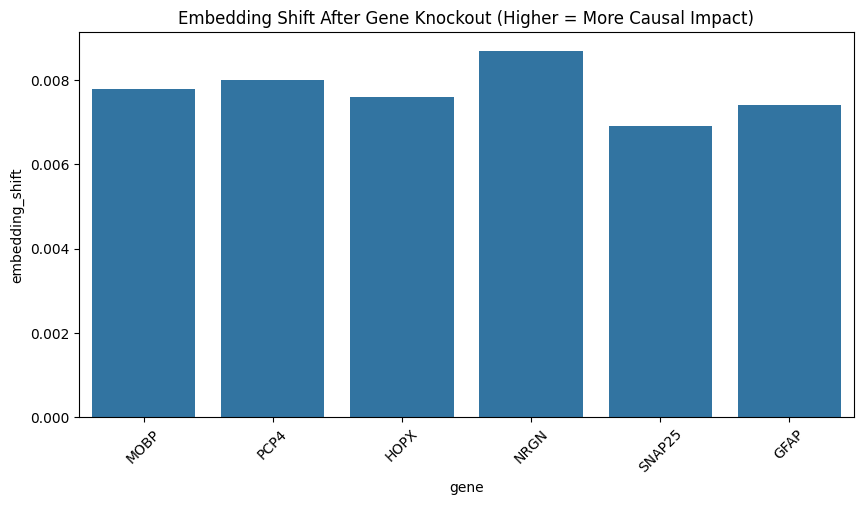

In [21]:
# ====================  Visualizations ====================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.spatial(adata, color='STAGATE_leiden', title='Baseline Domains', ax=axes[0], show=False)
sc.pl.spatial(adata_ko, color='STAGATE_ko_leiden', title=f'After {genes_to_test[0]} Knockout', ax=axes[1], show=False)
plt.tight_layout()
plt.savefig('baseline_vs_knockout.png', dpi=300)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='gene', y='embedding_shift')
plt.title('Embedding Shift After Gene Knockout (Higher = More Causal Impact)')
plt.xticks(rotation=45)
plt.savefig('knockout_impact.png', dpi=300)
plt.show()